needed multigrid iterations: 18


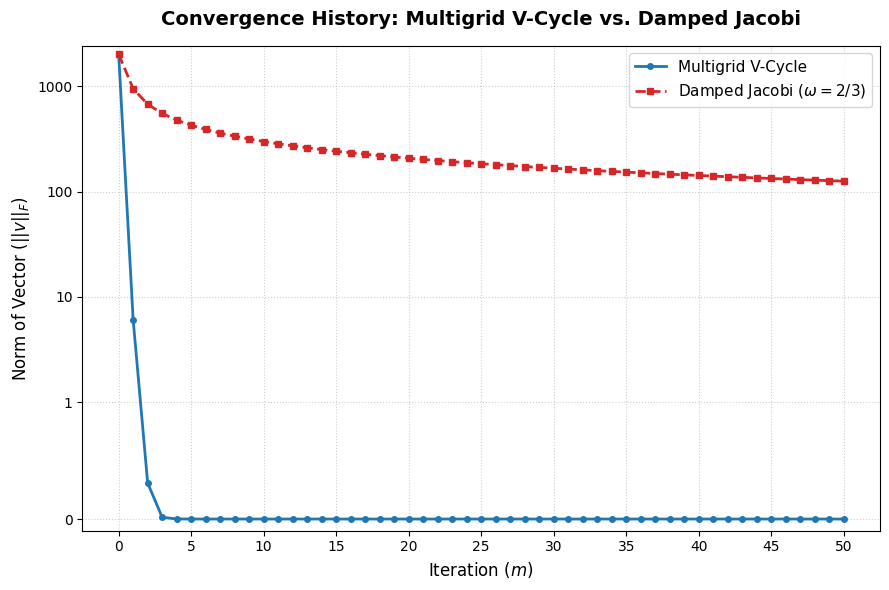

In [82]:
import numpy as np
import math

import torch
import matplotlib.pyplot as plt

from multigrid import laplace_multigrid_v_cycle
from utils import DirichletBoundaryCondition


# ====================
# SETUP
# ====================
n = 64
total_iterations = 50






def laplace_jacobi_1d_step(v: torch.Tensor, omega: float = 2/3) -> torch.Tensor:
    """
    Runs damped Jacobi for the 1D Laplace equation (Au = 0).
    Assumes homogeneous Dirichlet boundary conditions: v[0] = v[-1] = 0.

    Args:
        v: 1D torch.Tensor representing the current solution vector.
        omega: The damping factor (default 2/3 for optimal high-frequency damping).
    """
    v_out = v.clone()

    # 1D Laplace Jacobi step: 0.5 * (left_neighbor + right_neighbor)
    v_jacobi = 0.5 * (v_out[:-2] + v_out[2:])

    # Damped update for the interior points
    v_out[1:-1] = (1 - omega) * v_out[1:-1] + omega * v_jacobi


def damped_jacobi_step_2d(v, omega=2 / 3):
    """
    Performs exactly ONE step of the 2D damped Jacobi method for the
    Laplace equation on a uniform grid.

    Parameters:
    -----------
    u     : torch.Tensor
            A matrix of shape (n-1, n-1) containing the interior grid points WITH the boundaries.
    n     : int
            The number of grid intervals (interior points along one axis + 1).
    omega : float
            The damping factor (default: 2/3).

    Returns:
    --------
    torch.Tensor
            The updated interior matrix of shape (n-1, n-1) after one Jacobi step.
    """

    v_out = v.clone()


    # 2. Compute the standard, undamped Jacobi update for the interior.
    v_out[1:-1, 1:-1] = 0.25 * (
        v_out[0:-2, 1:-1] +  # Left neighbors
        v_out[2:,   1:-1] +  # Right neighbors
        v_out[1:-1, 0:-2] +  # Top neighbors
        v_out[1:-1, 2:  ]    # Bottom neighbors
    )

    # 3. Apply the relaxation factor combining the old interior state and the new update
    v_out[1:-1, 1:-1] = (1 - omega) * v[1:-1, 1:-1] + omega * v_out[1:-1, 1:-1]

    return v_out



def generate_multimode_initial_guess_in_2D(n):
    """
    Generates an n initial guess matrix containing a mix of
    low, mid, and high-frequency modes for a grid with n intervals.
    """
    # Number of interior points along one dimension

    # 1. Create a coordinate grid for interior points (indices 1 to n-1)
    # Using float64 for high numerical precision
    x = torch.linspace(1, n-1, n-1)
    y = torch.linspace(1, n-1, n-1)

    # Create 2D coordinate matrices of size (n-1) x (n-1)
    I, J = torch.meshgrid(x, y, indexing='ij')

    initial_guess = torch.zeros((n-1, n-1))

    for k1 in range(1, n):
        for k2 in range(1, n):
            mode = torch.sin((k1 * torch.pi * I) / n) * torch.sin((k2 * torch.pi * J) / n)
            initial_guess = initial_guess + mode

    return initial_guess








# create initial guess consisting of all modes
v_initial = generate_multimode_initial_guess_in_2D(n)


# ================================
# run Jacobi and Multigrid V-Cycle
# ================================

# =============
# run Multigrid
# =============

bc = DirichletBoundaryCondition.empty_w_size(n-1, n-1)
bc.left = 0
bc.right = 0
bc.bottom = 0
bc.top = 0

multigrid_norms = torch.zeros(total_iterations + 1)

v = v_initial.clone()
multigrid_norms[0] = v.norm()
for i in range(1, total_iterations + 1):
    v = laplace_multigrid_v_cycle(v, bc, int(math.log2(n)) - 1, 2/3, 0, 2)
    multigrid_norms[i] = v.norm()

    if multigrid_norms[i] == 0:
        print("needed multigrid iterations:", i)
        break


# ==========
# run Jacobi
# ==========

# 1. Pad the interior matrix with a 1-pixel border of zeros to represent the fixed boundary conditions.
# Total shape becomes (n+1, n+1)
v_initial_with_boundaries = torch.nn.functional.pad(v_initial, pad=(1, 1, 1, 1), mode='constant', value=0.0)

v = v_initial_with_boundaries.clone()
jacobi_norms[0] = v.norm()
for i in range(1, total_iterations + 1):
    v = damped_jacobi_step_2d(v, omega=2/3)
    jacobi_norms[i] = v.norm()

    if jacobi_norms[i] == 0:
        print("needed jacobi iterations:", i)
        break









# ====================
# plot the norms
# ====================

def plot_convergence(multigrid_norms, jacobi_norms):
    # Ensure arrays are on CPU and converted to numpy if they are PyTorch tensors
    if hasattr(multigrid_norms, 'detach'):
        multigrid_norms = multigrid_norms.detach().cpu().numpy()
    if hasattr(jacobi_norms, 'detach'):
        jacobi_norms = jacobi_norms.detach().cpu().numpy()

    m = len(multigrid_norms) - 1
    iterations = list(range(m + 1))

    plt.figure(figsize=(9, 6), dpi=100)

    # Plot both curves
    plt.plot(iterations, multigrid_norms, label='Multigrid V-Cycle',
             color='#1f77b4', linestyle='-', marker='o', markersize=4, linewidth=2)
    plt.plot(iterations, jacobi_norms, label='Damped Jacobi ($\\omega=2/3$)',
             color='#d62728', linestyle='--', marker='s', markersize=4, linewidth=2)

    # Apply symlog scale to handle 0 cleanly alongside 1000
    plt.yscale('symlog', linthresh=1.0)

    # Force the specific labels you requested
    y_ticks = [0, 1, 10, 100, 1000]
    plt.yticks(y_ticks, ['0', '1', '10', '100', '1000'])

    # Adjust limits dynamically based on data max
    max_val = max(np.max(multigrid_norms), np.max(jacobi_norms))
    plt.ylim(bottom=-0.1, top=max_val * 1.2)

    if m <= 50:
        plt.xticks(iterations[::max(1, m // 10)])

    plt.xlabel('Iteration ($m$)', fontsize=12)
    plt.ylabel('Norm of Vector ($||v||_F$)', fontsize=12)
    plt.title('Convergence History: Multigrid V-Cycle vs. Damped Jacobi', fontsize=14, fontweight='bold', pad=15)

    plt.grid(True, which="major", linestyle=':', alpha=0.6)
    plt.legend(fontsize=11, loc='upper right')
    plt.tight_layout()

    # This forces the window to open/render
    plt.savefig('examples/convergence_multigrid_vs_jacobi.pdf')
    plt.show()


plot_convergence(multigrid_norms, jacobi_norms)
